In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
training_df = pd.DataFrame()
training_df["order_amount"] = df.Amount

In [4]:
np.random.seed(42)

In [5]:
is_fraud = df.Class == 1

training_df["orders_last_24h"] = np.where(
    is_fraud,
    np.random.poisson(lam=8, size=len(df)),
    np.random.poisson(lam=1.5, size=len(df)),
)
training_df.orders_last_24h = training_df.orders_last_24h.clip(0, 20)

training_df["address_mismatch"] = np.where(
    is_fraud,
    np.random.choice([0, 1], size=len(df), p=[0.6, 0.4]),
    np.random.choice([0, 1], size=len(df), p=[0.85, 0.15]),
)

training_df["country_mismatch"] = np.where(
    is_fraud,
    np.random.choice([0, 1], size=len(df), p=[0.3, 0.7]),
    np.random.choice([0, 1], size=len(df), p=[0.99, 0.01]),
)

training_df["account_age_min"] = np.where(
    is_fraud,
    np.where(
        np.random.rand(len(df)) < 0.9,
        np.random.randint(1, 1440, size=len(df)),
        np.random.randint(1440, 10000, size=len(df)),
    ),
    np.where(
        np.random.rand(len(df)) < 0.2,
        np.random.randint(1, 1440, size=len(df)),
        np.random.randint(1440, 525600, size=len(df)),
    )
)

In [6]:
training_df.sample(10)

,order_amount,orders_last_24h,address_mismatch,country_mismatch,account_age_min
222147,8.98,3,0,0,343283
276612,77.00,1,1,0,186
57594,11.50,1,1,0,803
272467,40.00,0,0,0,45173
232264,14.96,1,0,0,89
79138,119.90,3,0,0,254221
227565,8.99,2,0,0,214341
242252,104.02,0,0,0,534
127687,4.49,1,0,0,136499
188922,15.00,1,0,0,943


In [7]:
X = training_df
y = df.Class

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)

model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train_res_scaled, y_train_res)

X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.35      0.91      0.51        98

    accuracy                           1.00     56962
   macro avg       0.68      0.95      0.75     56962
weighted avg       1.00      1.00      1.00     56962



In [8]:
X = training_df
y = df.Class

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)

model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train_res_scaled, y_train_res)

X_test_scaled = scaler.transform(X_test)
y_probs = model.predict_proba(X_test_scaled)[:, 1]
y_pred_adj = (y_probs > 0.7).astype(int)

print(classification_report(y_test, y_pred_adj, target_names=["Legit", "Fraud"]))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.45      0.87      0.59        98

    accuracy                           1.00     56962
   macro avg       0.73      0.93      0.80     56962
weighted avg       1.00      1.00      1.00     56962



In [9]:
X = training_df
y = df.Class

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)

model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train_res_scaled, y_train_res)

X_test_scaled = scaler.transform(X_test)
y_probs = model.predict_proba(X_test_scaled)[:, 1]
y_pred_adj = (y_probs > 0.7).astype(int)

print(classification_report(y_test, y_pred_adj, target_names=["Legit", "Fraud"]))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.60      0.89      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962



orders_last_24h     0.589950
country_mismatch    0.188232
account_age_min     0.171674
order_amount        0.049044
address_mismatch    0.001100
dtype: float64


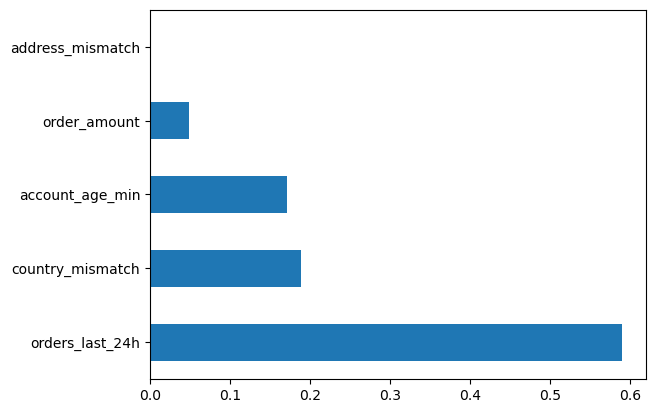

In [13]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances)
feature_importances.plot(kind="barh")
plt.show()